In [1]:
from typing import TypedDict, Annotated, Optional
from uuid import uuid4
from dotenv import load_dotenv
from langgraph.graph import END, StateGraph, add_messages
from langgraph.checkpoint.memory import MemorySaver
# LangChain LLM (Ollama)
from langchain_ollama import ChatOllama
# Tools
from langchain_community.tools.tavily_search import TavilySearchResults
load_dotenv()

True

In [2]:
llm = ChatOllama(
    model="llama3.2",  
    temperature=0
)

In [3]:
search_tool = TavilySearchResults(max_results=4)
tools = [search_tool]
llm_with_tools = llm.bind_tools(tools)
memory = MemorySaver()

/tmp/ipykernel_46945/4135366269.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(max_results=4)


In [4]:
response=llm_with_tools.invoke('What is the capital of France?')
response

AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-04-29T08:20:39.680041328Z', 'done': True, 'done_reason': 'stop', 'total_duration': 307224646323, 'load_duration': 583743208, 'prompt_eval_count': 187, 'prompt_eval_duration': 15554129144, 'eval_count': 43, 'eval_duration': 11018918998, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019dd84e-be4f-7e82-93fb-e81f495923b1-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': {'description': 'search query to look up', 'type': 'string', 'value': 'capital of France'}}, 'id': '49589b75-4c08-47a6-a0c1-9a4d43667530', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 187, 'output_tokens': 43, 'total_tokens': 230})

In [5]:
#building my Graph 
from langchain_core.messages import HumanMessage, AIMessageChunk, ToolMessage


In [6]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [7]:
async def model(state: State):
    result = await llm_with_tools.ainvoke(state["messages"])
    return {
        "messages": [result], 
    }


async def tools_router(state: State):
    last_message = state["messages"][-1]

    if(hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0):
        return "tool_node"
    else: 
        return END
    


async def tool_node(state):
    tool_calls = state["messages"][-1].tool_calls

    tool_messages = []

    for tool_call in tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_id = tool_call["id"]

        
        if isinstance(tool_args, dict):
            tool_args = (
                tool_args.get("query")
                or tool_args.get("value")
                or str(tool_args)
            )

        tool_args = str(tool_args) 

        if tool_name == "tavily_search_results_json":
            search_results = await search_tool.ainvoke({
                "query": tool_args  
            })

            tool_messages.append(
                ToolMessage(
                    content=str(search_results),
                    tool_call_id=tool_id,
                    name=tool_name
                )
            )

    return {"messages": tool_messages}

In [8]:
#building the Graph 
graph_builder = StateGraph(State);
graph_builder.add_node("model", model)
graph_builder.add_node("tool_node", tool_node)
graph_builder.set_entry_point("model")

graph_builder.add_conditional_edges("model", tools_router)
graph_builder.add_edge("tool_node", "model")

graph = graph_builder.compile(checkpointer=memory)

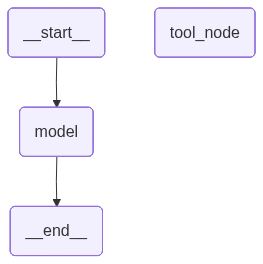

In [9]:
# Visualize the graph using Mermaid
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

In [10]:
config={
    "configurable": {
        "thread_id": '1'
    }
}
response=await graph.ainvoke({
    "messages": [HumanMessage(content="What is the capital of France?")]
}, config=config)
response

{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='da1308d8-de04-42f7-a923-d4b3f9cc575e'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-04-29T08:20:52.199418397Z', 'done': True, 'done_reason': 'stop', 'total_duration': 11570430536, 'load_duration': 378713681, 'prompt_eval_count': 187, 'prompt_eval_duration': 243628209, 'eval_count': 43, 'eval_duration': 10742332160, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019dd853-7228-7693-b15c-51decb34b6e4-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': {'description': 'search query to look up', 'type': 'string', 'value': 'capital of France'}}, 'id': '2e7797d3-05ee-47df-b378-1d2f63eeb8cf', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 187, 'output_tokens': 43, 'total_tokens': 230}),
  ToolMessage(content='[{\'title\': \'Paris

In [12]:
config = {
    "configurable": {
        "thread_id": 7
    }
}
async for event in graph.astream_events(
    {
        "messages": [
            HumanMessage(content="Give me a 100 word essay on climate change")
        ]
    },
    config=config,
    version="v2"
):
    if event["event"] == "on_chat_model_stream":
        chunk = event["data"]["chunk"]
        print(chunk.content, end="", flush=True)

Here is a 100-word essay on climate change:

Climate change refers to the long-term warming of the planet due to an increase in average global temperature. This phenomenon is primarily caused by human activities such as burning fossil fuels, deforestation, and industrial processes, which release greenhouse gases like carbon dioxide and methane into the atmosphere. These gases trap heat from the sun, leading to a rise in global temperatures. Climate change has severe consequences, including rising sea levels, more frequent natural disasters, and altered ecosystems. It is essential to reduce our carbon footprint by adopting sustainable practices, investing in renewable energy sources, and promoting eco-friendly policies.